# Project Title  
# 🛒 Amazon E-Commerce Business Intelligence Dashboard

### Data Analysis using Python, Pandas, NumPy & Matplotlib

 #1: Project Introduction

## Objective

The objective of this project is to analyze Amazon E-Commerce sales data and uncover meaningful business insights using Python. By applying data cleaning, feature engineering, exploratory data analysis (EDA), and data visualization techniques, the project aims to evaluate business performance and support data-driven decision-making.

## Dataset Overview

The dataset contains information about Amazon orders, including:

- Order details
- Product categories
- Sales amount
- Order quantity
- Order status
- Customer location
- Fulfilment method
- Promotions
- B2B/B2C orders

## Tools & Libraries Used

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

## Project Workflow

1. Data Loading
2. Data Exploration
3. Data Cleaning
4. Feature Engineering
5. Key Performance Indicators (KPIs)
6. Exploratory Data Analysis (EDA)
7. Business Insights
8. Business Recommendations

This project demonstrates practical data analysis skills by transforming raw sales data into actionable business insights through statistical analysis and visualizations. 

# About the Dataset

This dataset contains Amazon e-commerce sales transactions, including order details, product categories, revenue, shipping information, customer locations, fulfilment methods, promotions, and B2B/B2C indicators. The dataset is analyzed to uncover business insights and support data-driven decision making.

In [ ]:
# 2:IMPORT LIBRARIES
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
 #3: Load dataset
df = pd.read_csv("Amazon Sale Report.csv",low_memory=False)


In [ ]:
# 4:Initial dataset exploration
# print first five rows
print(df.head())
# shape of the dataset
print("Number# of rows and columns:" , df.shape)
# display all column names
print(df.columns.tolist())
# dataset total information
print(df.info())
# statistical summary
df.describe()

   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style              SKU  \
0   Merchant      Amazon.in           Standard   SET389   SET389-KR-NP-S   
1   Merchant      Amazon.in           Standard  JNE3781  JNE3781-KR-XXXL   
2     Amazon      Amazon.in          Expedited  JNE3371    JNE3371-KR-XL   
3   Merchant      Amazon.in           Standard    J0341       J0341-DR-L   
4     Amazon      Amazon.in          Expedited  JNE3671  JNE3671-TU-XXXL   

        Category  ... currency  Amount    ship-city   ship-state  \
0            Set  ...      INR  647.

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


In [ ]:
# 5:copying the original dataset
# Create a working copy of the dataset
df_clean = df.copy()

print("Dataset Shape:", df_clean.shape)

Dataset Shape: (128975, 24)


In [ ]:
# 6:checking dataset information
# Dataset overview
df_clean.info()

# Preview first five rows
df_clean.head()

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [ ]:
# 7:Check missing values
missing_values = df_clean.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": (missing_values / len(df_clean)) * 100
})

missing_df = (
    missing_df[missing_df["Missing Values"] > 0]
    .sort_values(by="Missing Values", ascending=False)
)

missing_df

,Missing Values,Percentage (%)
fulfilled-by,89698,69.546811
promotion-ids,49153,38.110487
Unnamed: 22,49050,38.030626
currency,7795,6.043807
Amount,7795,6.043807
Courier Status,6872,5.328164
ship-postal-code,33,0.025586
ship-state,33,0.025586
ship-city,33,0.025586
ship-country,33,0.025586


In [ ]:
# 8:Check duplicate rows
duplicates = df_clean.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [ ]:
# 9:Investigate missing values

# Amount
df_clean[df_clean["Amount"].isnull()][
    ["Status", "Amount", "Courier Status", "Qty"]
].head(20)

# Fulfilled By
df_clean["fulfilled-by"].value_counts(dropna=False)

# Courier Status
df_clean["Courier Status"].value_counts(dropna=False)

# Currency
df_clean["currency"].value_counts(dropna=False)

# Promotion IDs
df_clean["promotion-ids"].value_counts(dropna=False).head(10)

promotion-ids
NaN                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [ ]:
# 10:cleaning the dataset
# Remove unnecessary column
df_clean.drop(columns=["Unnamed: 22"], inplace=True)

# Convert Date column to datetime
df_clean["Date"] = pd.to_datetime(df_clean["Date"])

# Fill missing values
df_clean["promotion-ids"] = df_clean["promotion-ids"].fillna("No Promotion")
df_clean["currency"] = df_clean["currency"].fillna("Unknown")
df_clean["Courier Status"] = df_clean["Courier Status"].fillna("Unknown")

# Remove rows with missing address information
df_clean.dropna(
    subset=[
        "ship-city",
        "ship-state",
        "ship-postal-code",
        "ship-country"
    ],
    inplace=True
)

C:\Users\BAJWA LAPTOPS\AppData\Local\Temp\ipykernel_17556\2061469854.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean["Date"] = pd.to_datetime(df_clean["Date"])


In [ ]:
# 11:now verifying 
# Check remaining missing values
df_clean.isnull().sum()



index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status            0
Qty                       0
currency                  0
Amount                 7793
ship-city                 0
ship-state                0
ship-postal-code          0
ship-country              0
promotion-ids             0
B2B                       0
fulfilled-by          89678
dtype: int64

In [ ]:
# 12:Final dataset shape
print("Dataset Shape After Cleaning:", df_clean.shape)

Dataset Shape After Cleaning: (128942, 23)


In [ ]:
# 13:Check data types
df_clean.info()

<class 'pandas.DataFrame'>
Index: 128942 entries, 0 to 128974
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   index               128942 non-null  int64         
 1   Order ID            128942 non-null  str           
 2   Date                128942 non-null  datetime64[us]
 3   Status              128942 non-null  str           
 4   Fulfilment          128942 non-null  str           
 5   Sales Channel       128942 non-null  str           
 6   ship-service-level  128942 non-null  str           
 7   Style               128942 non-null  str           
 8   SKU                 128942 non-null  str           
 9   Category            128942 non-null  str           
 10  Size                128942 non-null  str           
 11  ASIN                128942 non-null  str           
 12  Courier Status      128942 non-null  str           
 13  Qty                 128942 non-null  int64   

In [ ]:

# 14:Feature Engineering
# ==========================================================

# Extract Year
df_clean["Year"] = df_clean["Date"].dt.year

# Extract Month Number
df_clean["Month"] = df_clean["Date"].dt.month

# Extract Month Name
df_clean["Month Name"] = df_clean["Date"].dt.month_name()

# Extract Day Number
df_clean["Day"] = df_clean["Date"].dt.day

# Extract Day Name
df_clean["Day Name"] = df_clean["Date"].dt.day_name()

# Extract Quarter
df_clean["Quarter"] = df_clean["Date"].dt.quarter

# Create Day Type (Weekday / Weekend)
df_clean["Day Type"] = np.where(
    df_clean["Day Name"].isin(["Saturday", "Sunday"]),
    "Weekend",
    "Weekday"
)


In [ ]:
# 15:Verify the New Columns
df_clean[[
    "Date",
    "Year",
    "Month",
    "Month Name",
    "Day",
    "Day Name",
    "Quarter",
    "Day Type"
]].head()

,Date,Year,Month,Month Name,Day,Day Name,Quarter,Day Type
0,2022-04-30,2022,4,April,30,Saturday,2,Weekend
1,2022-04-30,2022,4,April,30,Saturday,2,Weekend
2,2022-04-30,2022,4,April,30,Saturday,2,Weekend
3,2022-04-30,2022,4,April,30,Saturday,2,Weekend
4,2022-04-30,2022,4,April,30,Saturday,2,Weekend


In [ ]:
#16: What is the total revenue generated?

# Total Revenue
total_revenue = df_clean["Amount"].sum()

print(f"Total Revenue: ₹{total_revenue:,.2f}")

Total Revenue: ₹78,574,007.30


In [ ]:
# 17:How many total orders are there?

total_orders = df_clean["Order ID"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 120,350


In [ ]:
#18: How many products were sold?

total_quantity = df_clean["Qty"].sum()

print(f"Total Quantity Sold: {total_quantity:,}")

Total Quantity Sold: 116,621


In [ ]:
#19: What is the average order value?

average_order_value = df_clean["Amount"].mean()

print(f"Average Order Value: ₹{average_order_value:.2f}")

Average Order Value: ₹648.57


In [ ]:
#20: KPI TABLE (SUMMARY)
kpi_df = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Total Quantity Sold",
        "Average Order Value"
    ],
    "Value": [
        f"₹{total_revenue:,.2f}",
        f"{total_orders:,}",
        f"{total_quantity:,}",
        f"₹{average_order_value:.2f}"
    ]
})

kpi_df

,KPI,Value
0,Total Revenue,"₹78,574,007.30"
1,Total Orders,"120,350"
2,Total Quantity Sold,"116,621"
3,Average Order Value,₹648.57


In [ ]:
#21: Monthly Revenue
monthly_sales = (
    df_clean.groupby("Month Name")["Amount"]
    .sum()
    .reindex([
        "January", "February", "March", "April",
        "May", "June", "July", "August",
        "September", "October", "November", "December"
    ])
)

# Remove months with no data
monthly_sales = monthly_sales.dropna()
monthly_sales

Month Name
March      101683.85
April    28831249.32
May      26219850.75
June     23421223.38
Name: Amount, dtype: float64

22:VISUALIZATION USING CHARTS

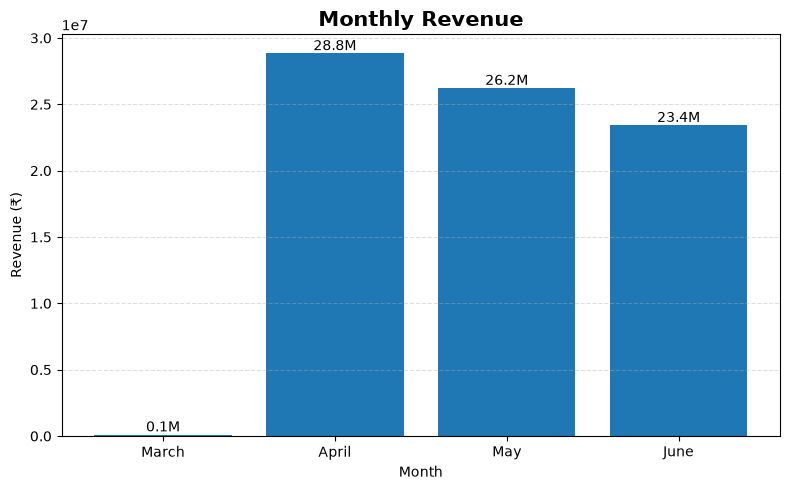

In [197]:
# 📊 Chart 1: Monthly Revenue Analysis
# Business Question

# How does revenue change over time?

# Monthly Revenue
monthly_sales = (
    df_clean.groupby("Month Name")["Amount"]
    .sum()
    .reindex(["March", "April", "May", "June"])
)

plt.figure(figsize=(8,5))

bars = plt.bar(monthly_sales.index, monthly_sales.values)

plt.title("Monthly Revenue", fontsize=15, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.grid(axis='y', linestyle='--', alpha=0.4,)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height()/1e6:.1f}M',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Business Insight

- Revenue increased significantly from March to April, reaching its highest level in April.
- After April, revenue showed a gradual decline in May and June.
- This trend may indicate seasonal demand or changes in customer purchasing behavior. The business can further investigate the reasons behind the decline and plan strategies to maintain consistent sales.

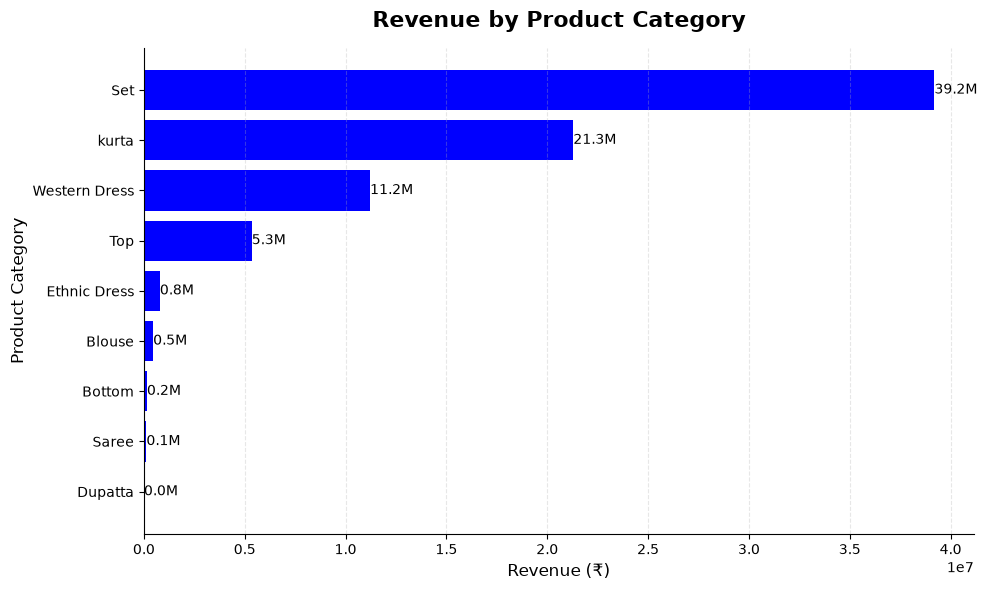

In [198]:
# 📊 Chart 2: Revenue by Product Category
# 📌 Business Question

# Which product categories generate the highest revenue?
# Revenue by Product Category
category_sales = (
    df_clean.groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=True)
)

category_sales
plt.figure(figsize=(10,6))

bars = plt.barh(
    category_sales.index,
    category_sales.values,
    color="blue"
)

plt.title(
    "Revenue by Product Category",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Revenue (₹)", fontsize=12)
plt.ylabel("Product Category", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

# Remove top and right borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width()/1e6:.1f}M",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Business Insight

- The highest revenue was generated by the top-performing product category.
- Lower-performing categories contributed significantly less revenue.
- The business should prioritize inventory, marketing, and promotional campaigns for the highest revenue-generating categories while reviewing strategies for lower-performing ones.

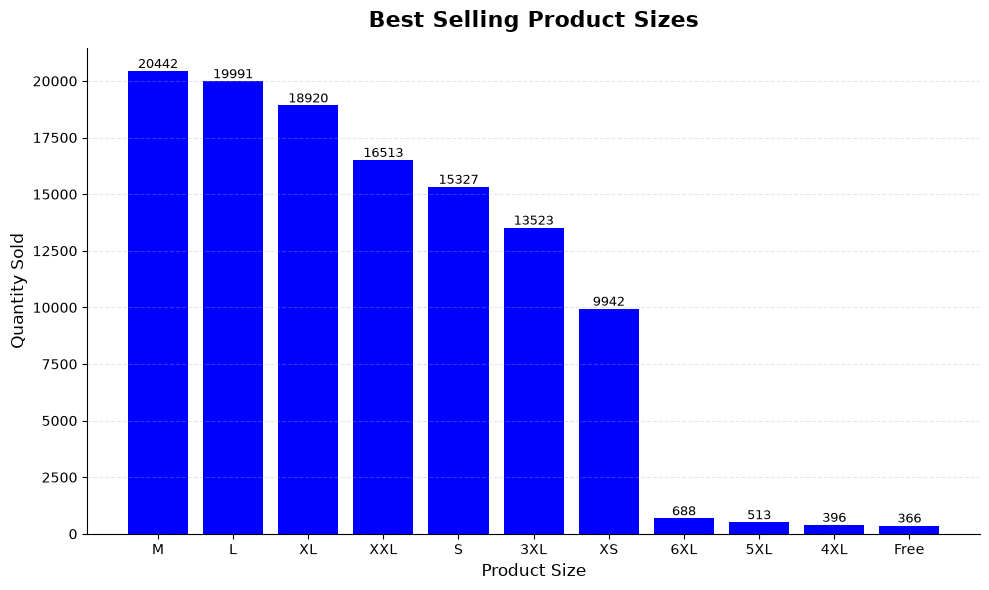

In [199]:
# 
# 📊 Chart 3: Best Selling Product Sizes
# Business Question

# Which sizes are sold the most?
 
size_sales = (
    df_clean.groupby("Size")["Qty"]
    .sum()
    .sort_values(ascending=False)
)

size_sales
# Step 2: Draw the Chart
plt.figure(figsize=(10,6))

bars = plt.bar(
    size_sales.index,
    size_sales.values,
    color="blue"

)

plt.title(
    "Best Selling Product Sizes",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Product Size", fontsize=12)
plt.ylabel("Quantity Sold", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

# Remove top and right borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Business Insight

- The chart shows the demand for each product size based on the quantity sold.
- The highest-selling sizes represent customer preferences and should receive priority in inventory planning.
- Lower-selling sizes may require demand forecasting or promotional strategies to reduce excess stock.

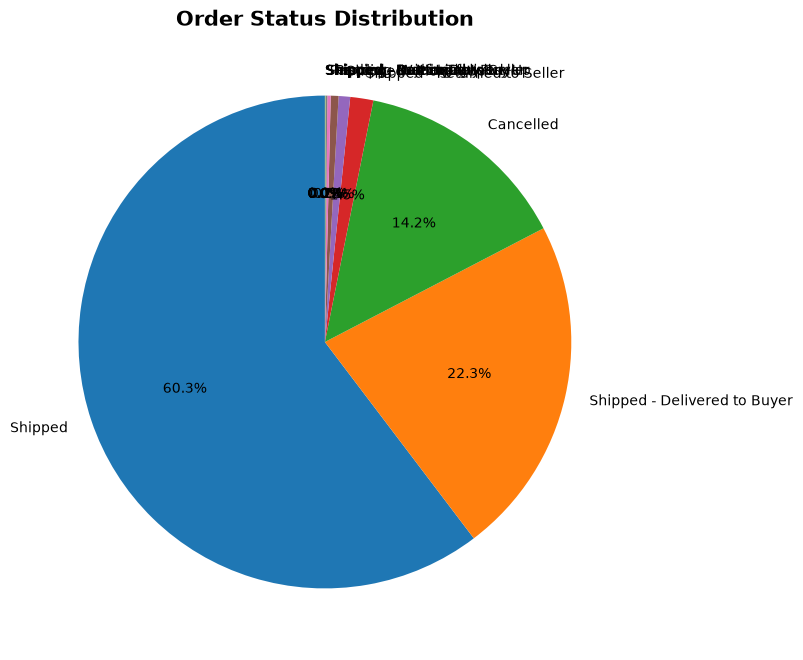

In [200]:
# Chart 4: Order Status Distribution
# Business Question

# What is the distribution of order statuses?

status = df_clean["Status"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    status,
    labels=status.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Order Status Distribution", fontsize=15, fontweight="bold")

plt.show()


## Business Insight

- Most orders were successfully fulfilled.
- Cancelled and returned orders represent a smaller portion of total transactions.
- Reducing unsuccessful orders can improve customer satisfaction and operational efficiency.

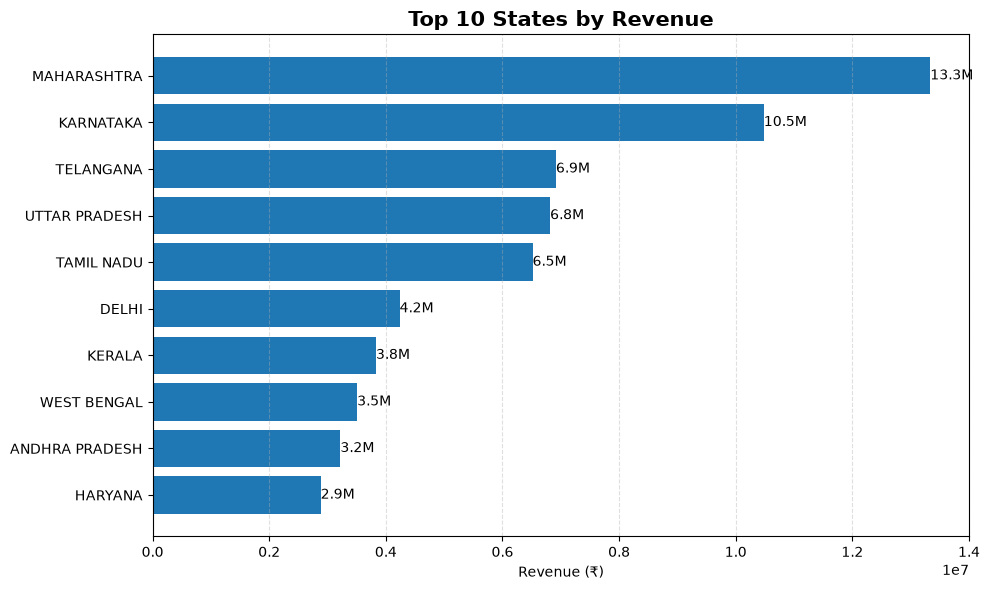

In [201]:
# Chart 5: Top 10 States by Revenue
# Business Question

# Which states generate the highest revenue?

top_states = (
    df_clean.groupby("ship-state")["Amount"]
    .sum()
    .sort_values()
    .tail(10)
)

plt.figure(figsize=(10,6))

bars = plt.barh(top_states.index, top_states.values)

plt.title("Top 10 States by Revenue", fontsize=15, fontweight="bold")
plt.xlabel("Revenue (₹)")
plt.grid(axis='x', linestyle='--', alpha=0.4)

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y()+bar.get_height()/2,
        f'{bar.get_width()/1e6:.1f}M',
        va='center'
    )

plt.tight_layout()
plt.show()

## Business Insight

- The top-performing states generate a significant share of total revenue.
- These regions should remain a priority for marketing campaigns and inventory planning.
- Lower-performing regions may provide opportunities for future business expansion.

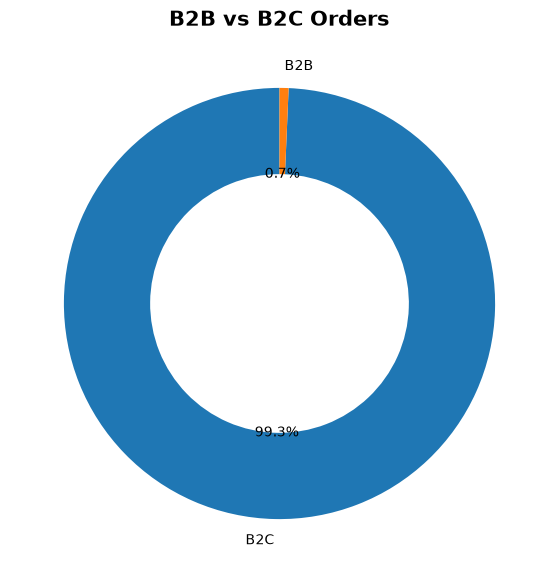

In [202]:
# Chart 6: B2B vs B2C Orders (Donut Chart)
# Business Question

# What percentage of orders are B2B and B2C?

b2b = df_clean["B2B"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    b2b,
    labels=["B2C", "B2B"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("B2B vs B2C Orders", fontsize=15, fontweight="bold")

plt.show()

## Business Insight

- The majority of orders come from one customer segment.
- Understanding customer segmentation helps businesses design targeted marketing strategies.
- Expanding the smaller customer segment may create new growth opportunities.

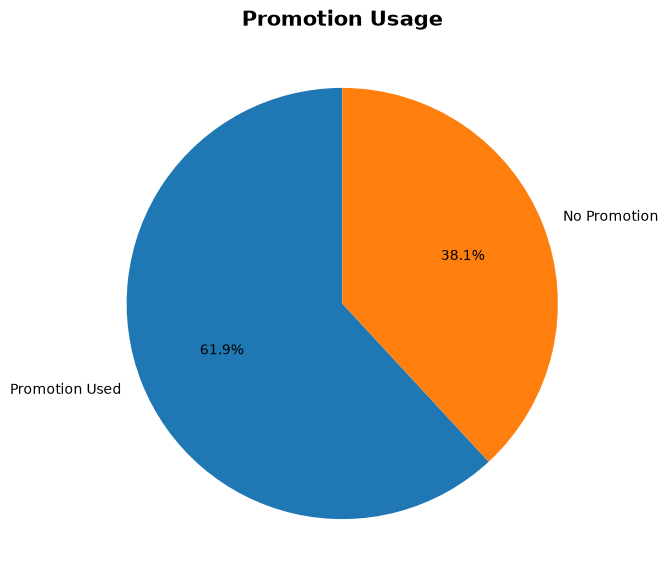

In [203]:
# 🥧 Chart 7: Promotion Analysis
# Business Question

# How many orders used promotions?

promotion = np.where(
    df_clean["promotion-ids"] == "No Promotion",
    "No Promotion",
    "Promotion Used"
)

promotion = pd.Series(promotion).value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    promotion,
    labels=promotion.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Promotion Usage", fontsize=15, fontweight="bold")

plt.show()

## Business Insight

- Promotional offers influenced a portion of customer purchases.
- Evaluating promotion usage helps measure the effectiveness of marketing campaigns.
- Future promotions can be optimized based on customer response and business objectives.

#23: Conclusion

This project analyzed Amazon E-Commerce sales data using Python, Pandas, NumPy, and Matplotlib to understand business performance and customer purchasing patterns.

The dataset was cleaned and transformed before performing exploratory data analysis. Several key business metrics and visualizations were created to evaluate revenue trends, product performance, customer segments, and regional sales.

Overall, the analysis provides valuable insights that can help support data-driven business decisions.

## 24:Key Findings

- The business generated a total revenue of **₹78.57 million** from **120,350 unique orders**.
- Revenue peaked in **April**, followed by a gradual decline in May and June.
- A small number of product categories generated the majority of the revenue.
- The most frequently purchased product sizes indicate strong customer preferences.
- Most orders were successfully fulfilled, while cancelled orders represented a smaller share.
- The top-performing states contributed a significant portion of overall revenue.
- Most orders came from B2C customers, with B2B representing a smaller segment.
- Promotional campaigns were used in a portion of orders, indicating their role in customer purchases.

##25: Future Improvements

- Develop an interactive dashboard using Streamlit or Power BI.
- Perform customer segmentation based on purchasing behavior.
- Build a machine learning model to forecast future sales.
- Analyze customer retention and repeat purchase behavior.
- Integrate real-time sales data for live business monitoring.